<a href="https://colab.research.google.com/github/Boommook/cs539-botbuster/blob/main/consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pandas.core.dtypes import missing
## Load and inspect the dataset
df = pd.read_csv("../data/raw/twitter_human_bots_dataset.csv")

print("Shape:", df.shape)
df.head()
df.info()

print("Class counts: ")  
print(df["account_type"].value_counts())
print()
print(df["account_type"].value_counts(normalize=True))
"""
missing_cnts = df.isna().sum()
missing_prcnts = (df.isna().mean() * 100)
missing_summary = pd.DataFrame({
    "missing_count": missing_cnts,
    "missing_percentage": missing_prcnts
})

# sort the table to the cols w the most missing vals appear first
missing_summary.sort_values(by="missing_cnts", ascending=False)

# display only columns that contain at least one missing value.
display(missing_summary[missing_summary["missing_count"] > 0])
"""

Shape: (37438, 20)
<class 'pandas.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    37438 non-null  int64  
 1   created_at                    37438 non-null  str    
 2   default_profile               37438 non-null  bool   
 3   default_profile_image         37438 non-null  bool   
 4   description                   30181 non-null  str    
 5   favourites_count              37438 non-null  int64  
 6   followers_count               37438 non-null  int64  
 7   friends_count                 37438 non-null  int64  
 8   geo_enabled                   37438 non-null  bool   
 9   id                            37438 non-null  int64  
 10  lang                          29481 non-null  str    
 11  location                      37434 non-null  str    
 12  profile_background_image_url  32939 non-null  str   

'\nmissing_cnts = df.isna().sum()\nmissing_prcnts = (df.isna().mean() * 100)\nmissing_summary = pd.DataFrame({\n    "missing_count": missing_cnts,\n    "missing_percentage": missing_prcnts\n})\n\n# sort the table to the cols w the most missing vals appear first\nmissing_summary.sort_values(by="missing_cnts", ascending=False)\n\n# display only columns that contain at least one missing value.\ndisplay(missing_summary[missing_summary["missing_count"] > 0])\n'

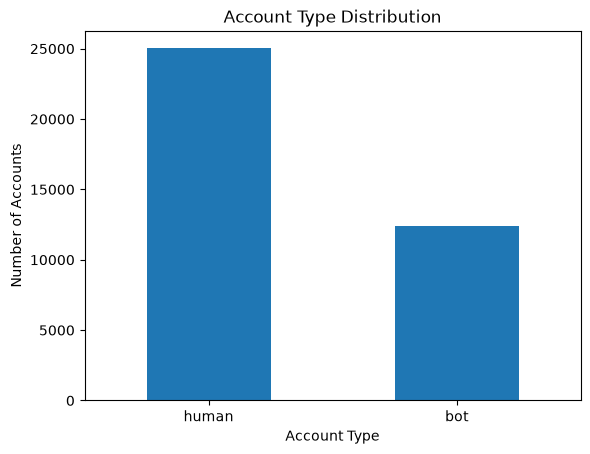

In [4]:
df["account_type"].value_counts().plot(kind="bar")

plt.title("Account Type Distribution")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)
plt.show()

Numerical Feature Distributions

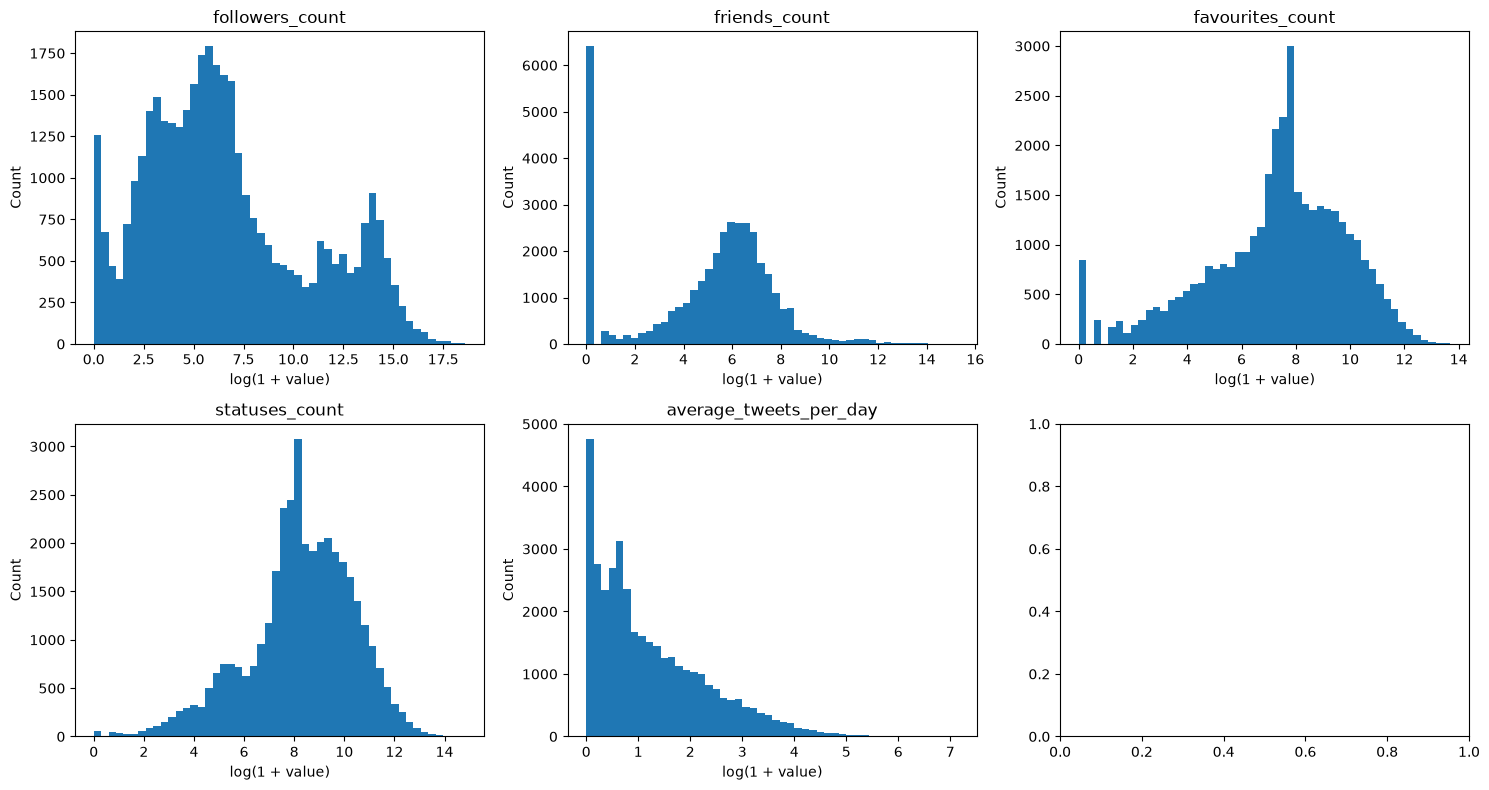

In [5]:
# I did this manually, but can be done dynamically too
numeric_cols = [
    "followers_count",
    "friends_count",
    "favourites_count",
    "statuses_count",
    "average_tweets_per_day"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    # log1p reduces the effect of extremely large values
    ax.hist(np.log1p(df[col]), bins=50)
    ax.set_title(col)
    ax.set_xlabel("log(1 + value)")
    ax.set_ylabel("Count")

# need to hide unused graph I think

plt.tight_layout()
plt.show()

Numerical Feature Comparison btwn Humans and Bots

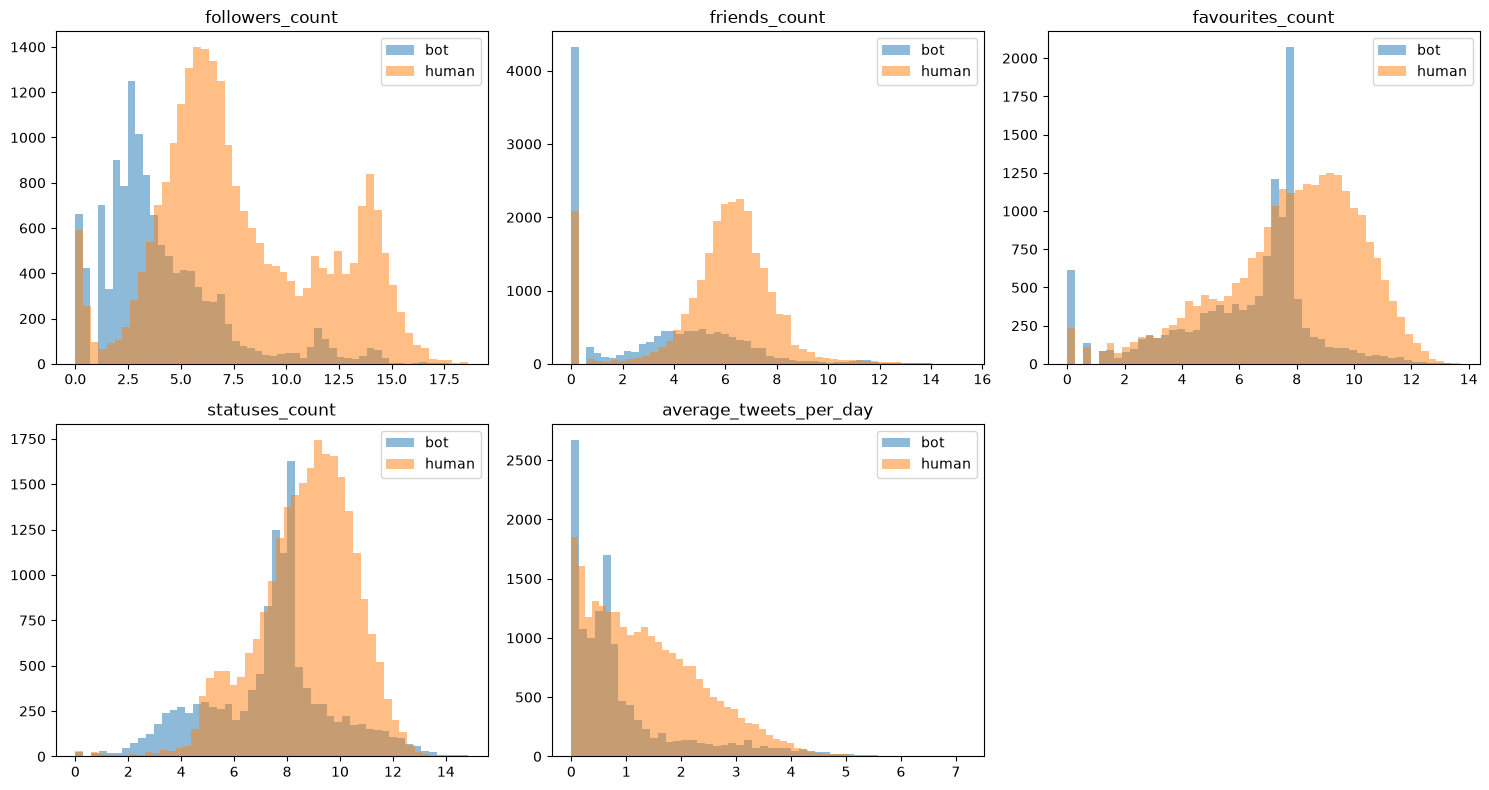

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    for label, group in df.groupby("account_type"):
        ax.hist(
            np.log1p(group[col]),
            bins=50,
            alpha=0.5,
            label=label
        )

    ax.set_title(col)
    ax.legend()

# I think this hides the unused graph (TO DO: ADD ABOVE TOO)
for ax in axes.flatten()[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Compare Accounts Ages

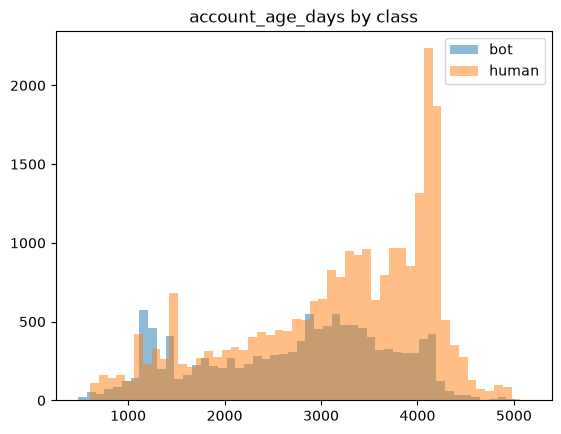

In [7]:
for label, group in df.groupby('account_type'):
    plt.hist(group['account_age_days'], bins=50, alpha=0.5, label=label)
plt.title('account_age_days by class')
plt.legend()
plt.show()

Box Plots by Type

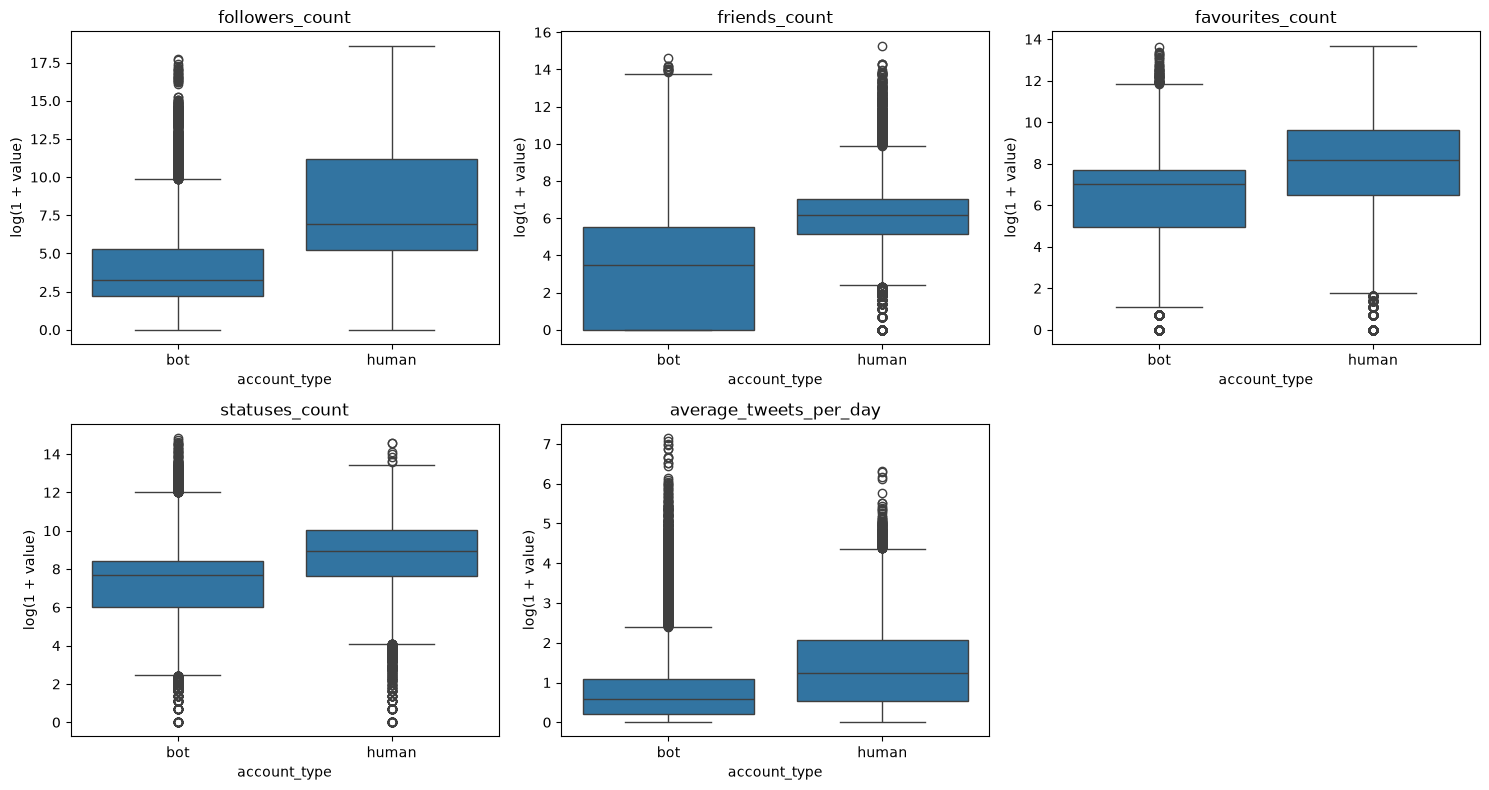

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(
        data=df,
        x="account_type",
        y=np.log1p(df[col]),
        ax=ax
    )

    ax.set_title(col)
    ax.set_ylabel("log(1 + value)")

# hide unused graph
for ax in axes.flatten()[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Examine Boolean Feature Relationships

In [9]:
boolean_cols = [
    "default_profile",
    "default_profile_image",
    "geo_enabled",
    "verified"
]

for col in boolean_cols:
    print(f"\n{col}")

    display(
        pd.crosstab(
            df[col],
            df["account_type"],
            normalize="index"
        )
    )


default_profile


account_type,bot,human
default_profile,,
False,0.215674,0.784326
True,0.492430,0.507570



default_profile_image


account_type,bot,human
default_profile_image,,
False,0.326518,0.673482
True,0.686380,0.313620



geo_enabled


account_type,bot,human
geo_enabled,,
False,0.476843,0.523157
True,0.159044,0.840956



verified


account_type,bot,human
verified,,
False,0.405159,0.594841
True,0.041849,0.958151


Correlation Heatmap

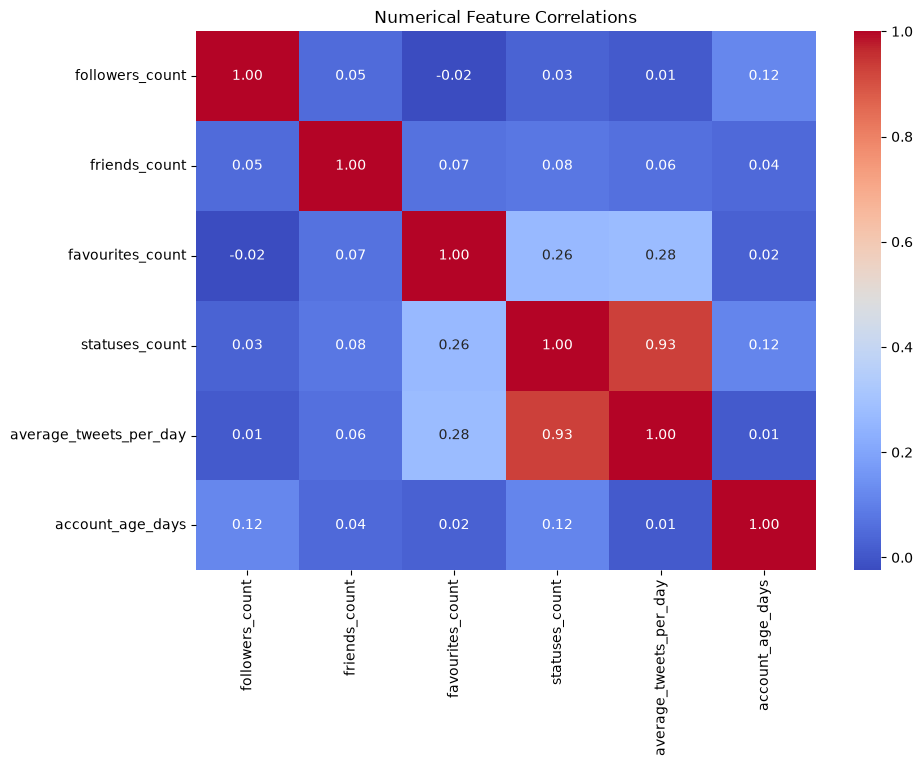

In [10]:
correlation_cols = numeric_cols + ["account_age_days"]

# we can change this if wanted
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlations")
plt.show()

Clean, Remove, and Add Features to the Dataset. Note: This could be broken lol

In [11]:
def engineer_features(df):
  """
  Clean, remove, and add features to the dataset.

  Returens a copy of the dataset containing the newly engineered feats
  """
  model_df = df.copy()

  # convert the text target into int labels
  model_df["account_is_bot"] = (
        model_df["account_type"]
        .map({
            "human": 0,
            "bot": 1
        })
        .astype(int)
    )

  # ---------------------------------------------------------
  # Clean/remove features
  # ---------------------------------------------------------

  # remove columns that are identifiers, dupes, or unlikely to generalize
  model_df = model_df.drop(
        columns=[
            "Unnamed: 0",
            "id",
            "created_at",
            "profile_background_image_url",
            "profile_image_url"
        ],
        errors="ignore"
    )

  # ---------------------------------------------------------
  # Mssing-val features
  # ---------------------------------------------------------
  model_df["description_missing"] = model_df["description"].isna()

  model_df["location_unknown"] = (
    model_df["location"].isna()
    | model_df["location"].fillna("").str.lower().eq("unknown")
  )
  model_df["language_missing"] = df["lang"].isna()


  # text-based feats
  description = df["description"].fillna("")
  screen_name = df["screen_name"].fillna("")

  # Description features
  model_df["description_length"] = description.str.len()
  model_df["description_word_count"] = description.str.split().str.len()
  model_df["description_mention_count"] = description.str.count(r"@\w+")
  model_df["description_hashtag_count"] = description.str.count(r"#\w+")
  model_df["description_digit_count"] = description.str.count(r"\d")
  model_df["description_exclamation_count"] = description.str.count("!")

  # Screen-name features
  model_df["screen_name_length"] = screen_name.str.len()
  model_df["screen_name_digit_count"] = screen_name.str.count(r"\d")
  model_df["screen_name_underscore_count"] = screen_name.str.count("_")

  ## return completed dataframe
  return model_df


Final Check

In [12]:
model_df = engineer_features(df)

print("Shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isnull().sum().sort_values(ascending=False).head())

display(model_df.head())

Shape: (37438, 28)

Missing values:
lang                7957
description         7257
location               4
default_profile        0
favourites_count       0
dtype: int64


,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,lang,location,screen_name,...,language_missing,description_length,description_word_count,description_mention_count,description_hashtag_count,description_digit_count,description_exclamation_count,screen_name_length,screen_name_digit_count,screen_name_underscore_count
0,False,False,"Blame @xaiax, Inspired by @MakingInvisible, us...",4,1589,4,False,en,unknown,best_in_dumbest,...,False,129,18,2,0,0,0,15,0,2
1,False,False,Photographing the American West since 1980. I ...,536,860,880,False,en,Estados Unidos,CJRubinPhoto,...,False,160,24,0,0,4,0,12,0,0
2,False,False,Scruffy looking nerf herder and @twitch broadc...,3307,172,594,True,en,"Los Angeles, CA",SVGEGENT,...,False,81,10,2,0,0,0,8,0,0
3,True,False,Wife.Godmother.Friend.Feline Fanatic! Assistan...,8433,517,633,True,en,"Birmingham, AL",TinkerVHELPK5,...,False,97,9,0,0,0,1,13,1,0
4,False,False,Loan coach at @mancity & Aspiring DJ,88,753678,116,True,en,"England, United Kingdom",JoleonLescott,...,False,36,7,1,0,0,0,13,0,0
